In [1]:
import numpy as np
import scipy
from dataset import inf_train_gen
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch
import math
import torch.nn as nn
from omegaconf import OmegaConf
import tqdm

In [2]:
TRAIN = 0

In [3]:
def energy_sample(env, ss, sample_per_state=1000, **kwargs):
    data, e = inf_train_gen(env,batch_size=1000*sample_per_state)
    #print(e.shape)
    ori_e = e
    e = e * ss

    index = np.random.choice(1000*sample_per_state, p=scipy.special.softmax(e).squeeze(), size=sample_per_state, replace=False)
    data = data[index]
    ori_e = ori_e[index]
    return data, ori_e

In [4]:
'''for task in ["8gaussians"]:
    plt.figure(figsize=(12,3.0))
    ss = [0,3, 10,20]
    axes = []
    for i, s in enumerate(ss):
        plt.subplot(1, len(ss), i+1)
        data, e = energy_sample(task, s, sample_per_state=2000)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlim(-4.5,4.5)
        plt.ylim(-4.5,4.5)
        if i == 0:
            mappable = plt.scatter(data[:,0],data[:,1],s=1,c=e,cmap="winter",vmin=0,vmax=1, rasterized=True)
            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])
        else:
            plt.scatter(data[:,0],data[:,1],s=1,c=e,cmap="winter",vmin=0,vmax=1, rasterized=True)
            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[None, None, None, None, None])
        axes.append(plt.gca())
        plt.xticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])
        plt.title(r'$\beta={}$'.format(s))
    plt.tight_layout()
    plt.gcf().colorbar(mappable, ax=axes, fraction=0.1, pad=0.02, aspect=12)'''

'for task in ["8gaussians"]:\n    plt.figure(figsize=(12,3.0))\n    ss = [0,3, 10,20]\n    axes = []\n    for i, s in enumerate(ss):\n        plt.subplot(1, len(ss), i+1)\n        data, e = energy_sample(task, s, sample_per_state=2000)\n        plt.gca().set_aspect(\'equal\', adjustable=\'box\')\n        plt.xlim(-4.5,4.5)\n        plt.ylim(-4.5,4.5)\n        if i == 0:\n            mappable = plt.scatter(data[:,0],data[:,1],s=1,c=e,cmap="winter",vmin=0,vmax=1, rasterized=True)\n            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])\n        else:\n            plt.scatter(data[:,0],data[:,1],s=1,c=e,cmap="winter",vmin=0,vmax=1, rasterized=True)\n            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[None, None, None, None, None])\n        axes.append(plt.gca())\n        plt.xticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])\n        plt.title(r\'$\x08eta={}$\'.format(s))\n    plt.tight_layout()\n    plt.gcf().colorbar(mappable, ax=axes, fraction=0.1, pad=0.02, a

In [5]:

def get_8gaussian_centers(scale=4.0):
    # Recreating the centers from your inf_train_gen code
    centers = [
        (0, 1), (1/2**0.5, 1/2**0.5), (1, 0), (1/2**0.5, -1/2**0.5),
        (0, -1), (-1/2**0.5, -1/2**0.5), (-1, 0), (-1/2**0.5, 1/2**0.5)
    ]
    # Note: your code centers start from (0,1) and go clockwise/counter-clockwise.
    # We scale and convert to tensor
    return torch.tensor(centers) * scale / 1.414 # Dividing by 1.414 as per your dataset normalization

def energy_function_x0(x0, centers):
    """
    E(x0) = sum_{i=0}^7 (i/7) * 1(x0 in Mode_i)
    """
    # x0: [batch, 2], centers: [8, 2]
    # Compute squared distances to all 8 centers
    dist = torch.cdist(x0, centers) # [batch, 8]
    
    # Find the index of the closest center (the indicator function 1(x0 in Mode_i))
    nearest_idx = torch.argmin(dist, dim=1) 
    
    # Map index to energy value (i/7)
    energy = nearest_idx.float() / 7.0
    return energy.unsqueeze(-1)

def visualization_energy(x0, centers, beta=1.0):
    """Calculates exp(-beta * E(x0)) for plotting"""
    energy = energy_function_x0(x0, centers)
    return torch.exp(-beta * energy)

In [9]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # Standard sinusoidal embedding used in DDPM
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=t.device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ScoreModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            TimeEmbedding(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        
        self.mid_layer = nn.Sequential(
            nn.Linear(input_dim + hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim) # Output: same shape as input
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        # Concatenate noisy input with time information
        x_input = torch.cat([x, t_emb], dim=-1)
        return self.mid_layer(x_input)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ScoreModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Hyperparameters
T = 1000
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

def train_step(batch_size=512):
    # 1. Sample real data
    x_0, _ = inf_train_gen("8gaussians", batch_size=batch_size)
    x_0 = torch.from_numpy(x_0).to(device)
    
    # 2. Sample random timesteps
    t = torch.randint(0, T, (batch_size,), device=device).long()
    
    # 3. Add noise (Forward Process)
    noise = torch.randn_like(x_0)
    sqrt_alpha_cumprod = torch.sqrt(alphas_cumprod[t])[:, None]
    sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - alphas_cumprod[t])[:, None]
    
    x_t = sqrt_alpha_cumprod * x_0 + sqrt_one_minus_alpha_cumprod * noise
    
    # 4. Predict noise and compute MSE Loss
    optimizer.zero_grad()
    predicted_noise = model(x_t, t)
    loss = nn.MSELoss()(predicted_noise, noise)
    
    loss.backward()
    optimizer.step()
    return loss.item()

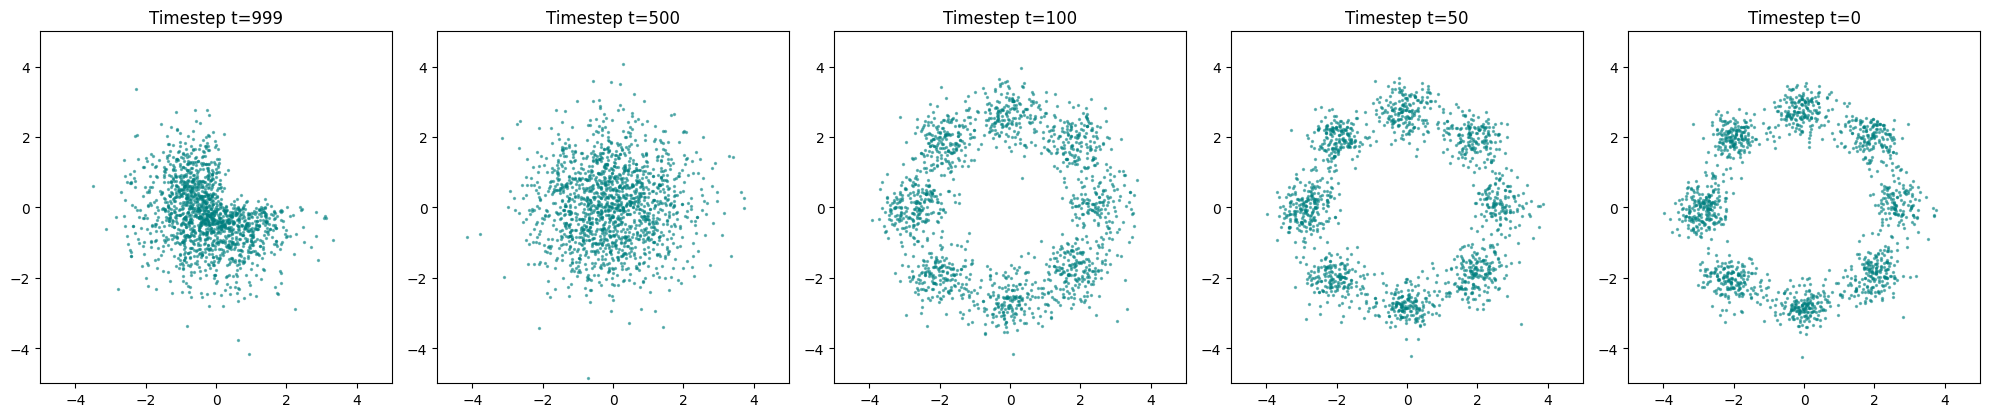

In [8]:

# --- Training Execution ---
def train_model(model, iterations=5000, batch_size=512):
    model.train()
    for i in range(iterations):
        loss_val = train_step(batch_size)
        if i % 1000 == 0:
            print(f"Iteration {i}, Loss: {loss_val:.4f}")

# --- Reverse Diffusion Plotting ---
def plot_reverse_diffusion(model, steps=[999, 500, 100, 50, 0], num_samples=2000):
    model.eval()
    device = next(model.parameters()).device
    
    # Start with pure noise
    x = torch.randn((num_samples, 2)).to(device)
    mask = (x < 0).any(dim=1)
    x = x[mask]
    # Prepare the plot
    fig, axes = plt.subplots(1, len(steps), figsize=(20, 4))
    
    # Pre-calculate alpha components for sampling
    # (Using the standard DDPM sampling step)
    with torch.no_grad():
        for i in reversed(range(T)):
            t_idx = torch.full((num_samples,), i, device=device, dtype=torch.long)
            t_idx = t_idx[mask]
            # Predict noise
            eps_pred = model(x, t_idx)
            
            # DDPM Step
            alpha_t = alphas[i]
            alpha_cp_t = alphas_cumprod[i]
            beta_t = betas[i]
            
            if i > 0:
                noise = torch.randn_like(x)
            else:
                noise = 0
                
            # Compute x_{t-1}
            x = (1 / torch.sqrt(alpha_t)) * (x - ((1 - alpha_t) / torch.sqrt(1 - alpha_cp_t)) * eps_pred)
            x = x + torch.sqrt(beta_t) * noise
            
            # If current step is in our "steps" list, plot it
            if i in steps:
                ax_idx = steps.index(i)
                data_np = x.cpu().numpy()
                axes[ax_idx].scatter(data_np[:, 0], data_np[:, 1], s=2, alpha=0.5, color='teal')
                axes[ax_idx].set_title(f"Timestep t={i}")
                axes[ax_idx].set_xlim(-5, 5)
                axes[ax_idx].set_ylim(-5, 5)
                axes[ax_idx].set_aspect('equal')

    plt.tight_layout()
    plt.show()

# Execution
if TRAIN == True:
    train_model(model, iterations=10000)
else:
    model.load_state_dict(torch.load('noise_pred_8gauss.pth', weights_only=True))
    #model.eval()
plot_reverse_diffusion(model)

In [9]:
#torch.save(model.state_dict(), 'noise_pred_8gauss.pth')

### Score based prediction

In [2]:
from diff_sde import dpm_solver_pytorch
from diff_sde.unconditional_model import *
from exp_energy_train import *

/home/arka/Documents/exp_energy/diff_sde/dpm_solver_pytorch.py:55: SyntaxWarning: invalid escape sequence '\h'
  The `alphas_cumprod` is the \hat{alpha_n} arrays in the notations of DDPM. Specifically, DDPMs assume that


In [3]:
args = bandit_get_args()
marginal_prob_std_fn = functools.partial(marginal_prob_std, device=args.device)
score_model= Bandit_MlpScoreNet(input_dim=2, output_dim=2, marginal_prob_std=marginal_prob_std_fn, args=args).to(args.device)


**************************
Namespace(env='8gaussians', seed=0, expid='default', device='cuda', save_model=1, debug=0, alpha=3.0, diffusion_steps=15, method='CEP')


/home/arka/Documents/exp_energy/diff_sde/schedule.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/home/arka/Documents/exp_energy/diff_sde/schedule.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/home/arka/Documents/exp_energy/diff_sde/schedule.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
/home/arka/Documents/exp_energy/diff_sde/schedule.py:5: UserWarning: To copy construct from a tensor, it is recommended to use source

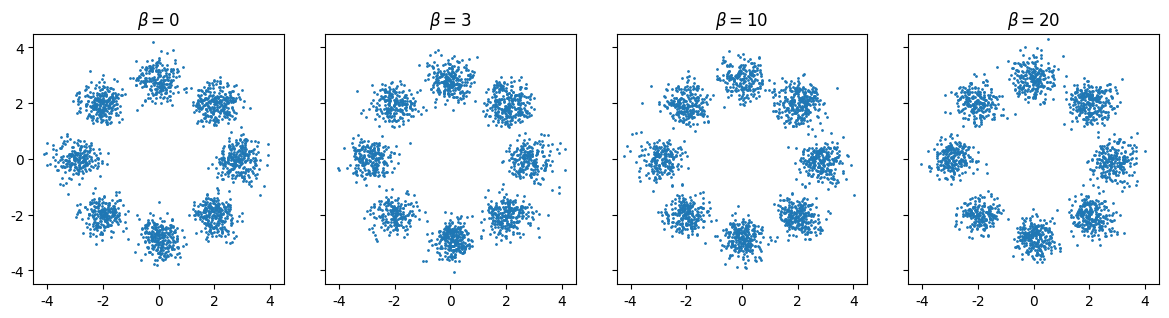

In [4]:
method = "CEP" # ["mse", "emse", "CEP"]
for task in ["8gaussians"]:
    plt.figure(figsize=(12,3.0))
    ss = [0,3, 10,20]
    axes = []
    for i, s in enumerate(ss):
        plt.subplot(1, len(ss), i+1)
        alpha=s
        ckpt = torch.load("./models/8gaussians0CEP_alpha3/ckpt100.pth".format(task, method, alpha if alpha > 2 else 3), map_location=args.device)
        score_model.load_state_dict(ckpt) #I have to care only about this

        ckpt = torch.load("./models/8gaussians0CEP_alpha3/critic_ckpt100.pth".format(task, method, alpha if alpha > 2 else 3), map_location=args.device)
        score_model.q[0].load_state_dict(ckpt)

        score_model.q[0].guidance_scale = 1.0 if alpha >1 else 0.0
        data = score_model.sample(None, sample_per_state=2000, diffusion_steps=25)

        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlim(-4.5,4.5)
        plt.ylim(-4.5,4.5)
        if i == 0:
            mappable = plt.scatter(data[:,0],data[:,1],s=1, rasterized=True)
            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])
        else:
            plt.scatter(data[:,0],data[:,1],s=1, rasterized=True)
            plt.yticks(ticks=[-4, -2, 0, 2, 4],labels=[None, None, None, None, None])
        axes.append(plt.gca())
        plt.xticks(ticks=[-4, -2, 0, 2, 4],labels=[-4, -2, 0, 2, 4])
        plt.title(r'$ \beta ={}$'.format(s))
    plt.tight_layout()

In [13]:
from diff_sde import dpm_solver_pytorch

my_schedule = dpm_solver_pytorch.NoiseScheduleVP('linear')
my_score_model= MyScoreNet(input_dim=2, output_dim=2,marginal_prob_std=marginal_prob_std_fn, args=args).to(args.device)
ckpt = torch.load("./models/8gaussians0CEP_alpha3/ckpt100.pth".format(task, method, alpha if alpha > 2 else 3), map_location=args.device)
my_score_model.load_state_dict(ckpt) #I have to care only about this

x = torch.randn((2000, 2)).to(device)
mask = (x <0).any(dim=1)
x = x[mask]
my_data = my_score_model.sample_no_guide(x,my_schedule, diffusion_steps=25)

/home/arka/Documents/exp_energy/diff_sde/schedule.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)


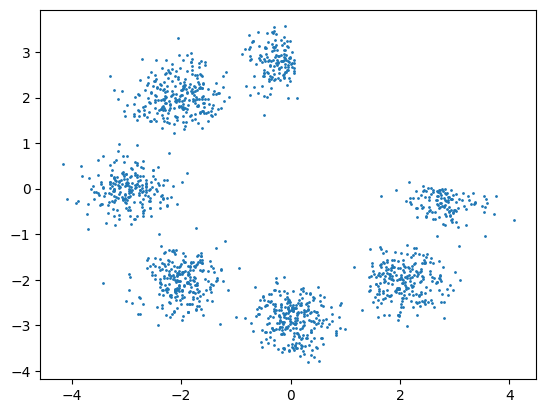

In [15]:
plt.scatter(my_data[:,0], my_data[:,1], s=1)

In [5]:

def get_8gaussians_energy_fn(scale=4.0):
    # 1. Recreate the centers exactly as in your inf_train_gen
    angles = torch.linspace(0, 2 * math.pi, 9)[:-1]
    # Adjusting for the specific order in your centers list (starting at (0,1) and going CCW)
    centers = torch.stack([-torch.sin(angles), torch.cos(angles)], dim=1) * scale
    centers = centers / 1.414 # Apply the normalization used in your code
    
    # 2. Assign rewards (0/7 to 7/7)
    rewards = torch.linspace(0, 1, 8)*10

    def energy_fn(x):
        """
        x: tensor of shape (batch, 2)
        Returns: scalar energy for each point
        """
        # Calculate squared distance from each point to each center
        # x: (B, 2), centers: (8, 2) -> dists: (B, 8)
        dists = torch.cdist(x, centers.to(x.device))**2
        
        # Soft-assignment: use a small temperature to find the nearest cluster 
        # while keeping the function differentiable.
        weights = torch.softmax(-dists * 10.0, dim=1) 
        
        # Multiply weights by rewards: (B, 8) * (8,) -> (B,)
        energy = torch.sum(weights * rewards.to(x.device), dim=1)
        return energy

    return energy_fn

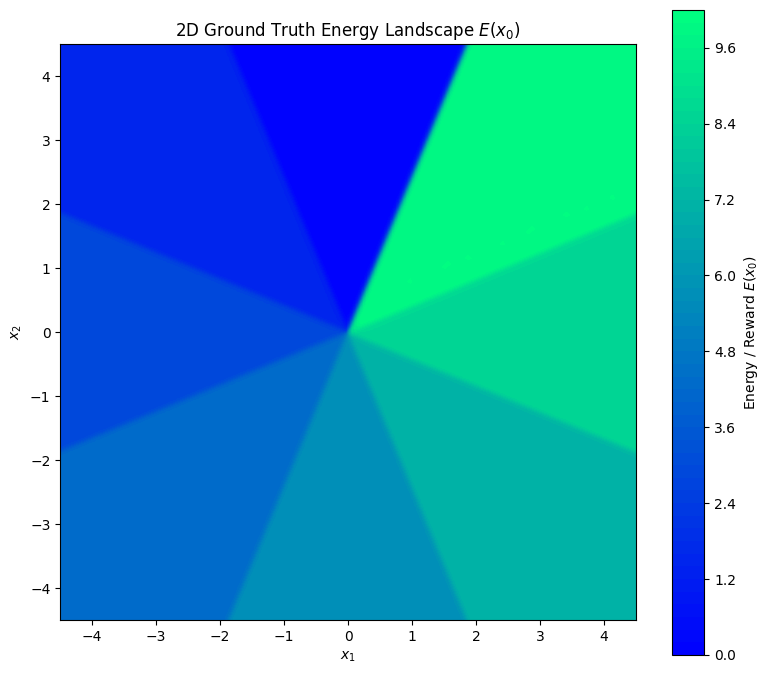

In [6]:
def plot_2d_energy_landscape(energy_fn, resolution=200):
    # 1. Define the spatial bounds based on your 8gaussians scaling
    # Since centers are at scale 4.0 and divided by 1.414, ~2.8 is the radius.
    limit = 4.5
    x_range = np.linspace(-limit, limit, resolution)
    y_range = np.linspace(-limit, limit, resolution)
    X, Y = np.meshgrid(x_range, y_range)
    
    # 2. Prepare grid for torch (Shape: [N*N, 2])
    grid_points = np.stack([X.ravel(), Y.ravel()], axis=1)
    grid_tensor = torch.from_numpy(grid_points).float()
    
    # 3. Compute Energy
    with torch.no_grad():
        # energy_fn should return (Batch_size,)
        Z = energy_fn(grid_tensor).cpu().numpy()
    
    Z = Z.reshape(resolution, resolution)
    
    # 4. Plotting
    plt.figure(figsize=(8, 7))
    
    # Use 'winter' or 'viridis' to match the paper's style
    contour = plt.contourf(X, Y, Z, levels=50, cmap='winter')
    plt.colorbar(contour, label='Energy / Reward $E(x_0)$')
    
    # Label the individual modes to show the 0.0 to 1.0 gradient
    plt.title("2D Ground Truth Energy Landscape $E(x_0)$")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.gca().set_aspect('equal')
    
    # Add a marker for the highest reward cluster
    # Based on index/7, the last cluster (index 7) is the maximum
    plt.tight_layout()
    plt.show()

# Run the plot
energy_fn = get_8gaussians_energy_fn(scale=4.0)
plot_2d_energy_landscape(energy_fn)

In [ ]:


def dps_sample(model, energy_fn, shape, steps=100, eta=20.0, device="cpu"):
    """
    Diffusion Posterior Sampling for 2D Gaussian experiment.
    
    Args:
        model: The trained score-based or diffusion model (returns epsilon or score).
        energy_fn: The energy function E(x) we want to minimize/guide towards.
        shape: Batch shape (batch_size, 2).
        steps: Number of diffusion steps.
        eta: Guidance scale (step size for the energy gradient).
    """
    # 1. Initialize from pure noise
    x = torch.randn(shape).to(device)
    
    # Define time schedule (simple linear)
    betas = torch.linspace(1e-4, 0.02, steps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    for i in reversed(range(steps)):
        t = torch.full((shape[0],), i, device=device, dtype=torch.long)
        
        # Enable gradient calculation for x to compute dE/dx
        x.requires_grad_(True)
        
        # 2. Predict x_0 (Posterior Mean Estimate)
        # Based on Tweedie's formula: x_0_hat = (x_t - sqrt(1-alpha)*eps) / sqrt(alpha)
        eps_pred = model(x, t)
        
        alpha_t = alphas_cumprod[i]
        x0_hat = (x - torch.sqrt(1 - alpha_t) * eps_pred) / torch.sqrt(alpha_t)
        
        # 3. Guidance: Compute gradient of energy w.r.t x_t
        energy = energy_fn(x0_hat).sum()
        grad_e = torch.autograd.grad(energy, x)[0]
        
        # 4. Update step (Langevin-style or DDIM-style + guidance)
        with torch.no_grad():
            # Standard reverse step (simplified DDPM)
            noise = torch.randn_like(x) if i > 0 else 0
            alpha_prev = alphas_cumprod[i-1] if i > 0 else torch.tensor(1.0)
            
            # The DPS core: Shift the mean by -eta * grad_e
            x = x0_hat * torch.sqrt(alpha_prev) + torch.sqrt(1 - alpha_prev) * eps_pred
            x = x - eta * grad_e  # Guidance step
            
            if i > 0:
                x = x + torch.sqrt(betas[i]) * noise
        
        x = x.detach()
        
    return x.cpu().numpy()

# Example Energy Function for 8 Gaussians 
# (e.g., guiding towards a specific quadrant or value)
def target_energy(x):
    # Example: Guide toward the center or a specific 'high reward' Gaussian
    # In the paper, this is usually the learned reward/energy model
    return torch.norm(x - torch.tensor([2.0, 2.0]).to(x.device), dim=-1)

In [ ]:
x_dps = dps_sample(model, energy_fn, (4000,2), device = device)

(-8.0, 8.0)

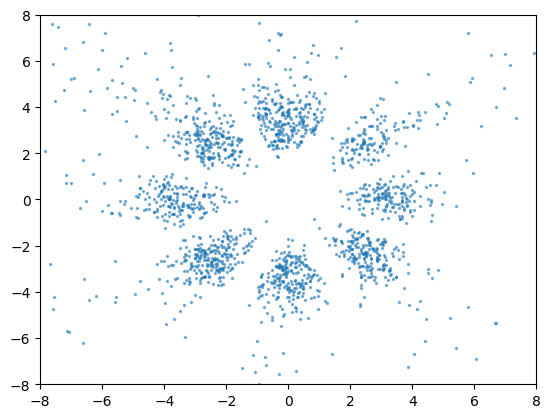

In [ ]:
plt.scatter(x_dps[:,0], x_dps[:,1], s=2, alpha=0.5)
plt.xlim(-8, 8)
plt.ylim(-8, 8)


### DAPS-Energy

In [ ]:
#from scheduler import LinearSchedule

In [11]:
class ReverseDDPMNoise():
    def __init__(self, scheduler, model, T = 1000):
        self.scheduler = scheduler
        self.model = model
        self.T = T
    
    
    def provide_x0(self, x_t):

        with torch.no_grad():
            for i in reversed(range(self.T)):
                if i == 1: #Fix this
                    break

                #t_idx = torch.full((self.num_samples,), i, device=device, dtype=torch.long)
                t_idx = torch.full((x_t.shape[0],), i, device=device, dtype=torch.long)
                # Predict noise
                eps_pred = model(x_t, t_idx)
                #print(eps_pred)
                
                # DDPM Step
                alpha_t = self.scheduler.alpha[i]
                alpha_cp_t = self.scheduler.alpha_bar[i]
                beta_t = self.scheduler.beta[i]
                
                if i > 0:
                    noise = torch.randn_like(x_t)
                else:
                    noise = 0
                    
                # Compute x_{t-1}
                x_t = (1 / torch.sqrt(alpha_t)) * (x_t - ((1 - alpha_t) / torch.sqrt(1 - alpha_cp_t)) * eps_pred)
                x_t = x_t + torch.sqrt(beta_t) * noise
                
                
        return x_t

In [12]:
from diff_sde import dpm_solver_pytorch

my_schedule = dpm_solver_pytorch.NoiseScheduleVP('linear')
my_score_model= MyScoreNet(input_dim=2, output_dim=2,marginal_prob_std=marginal_prob_std_fn, args=args).to(args.device)
ckpt = torch.load("./models/8gaussians0CEP_alpha3/ckpt100.pth".format(task, method, alpha if alpha > 2 else 3), map_location=args.device)
my_score_model.load_state_dict(ckpt) #I have to care only about this

x = torch.randn((2000, 2)).to(device)
mask = (x <0).any(dim=1)
x = x[mask]
my_data = my_score_model.sample_no_guide(x,my_schedule, diffusion_steps=25)

/home/arka/Documents/exp_energy/diff_sde/schedule.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)


In [13]:
from diff_sde import dpm_solver_pytorch
class RerverseDiff():
    def __init__(self, scheduler, score_model, diffusion_steps = 25):
        self.scheduler = scheduler
        self.score_model = score_model
        self.diffusion_steps = diffusion_steps

    def provide_x0(self, x_t):
        x0 = self.score_model.sample_no_guide(x_t, self.scheduler, diffusion_steps = self.diffusion_steps)
        return x0

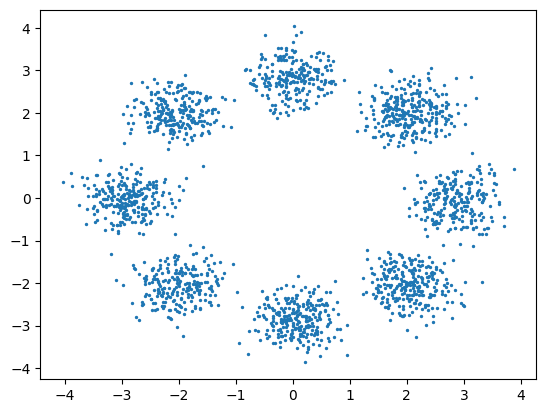

In [14]:
test_rev_diff = RerverseDiff(my_schedule, my_score_model)
test_rev_x0 = test_rev_diff.provide_x0(torch.randn((2000, 2)).to(device))
test_rev_x0 = test_rev_x0.cpu().numpy()
plt.scatter(test_rev_x0[:,0], test_rev_x0[:,1], s=2)

In [17]:
'''test_scheduler = LinearSchedule(1000, 1e-4, 0.02)
test_reverse = ReverseDDPMNoise(test_scheduler, model, 1000)
test_x0 = test_reverse.provide_x0(torch.randn((2000, 2)).to(device))
test_x0 = test_x0.cpu().numpy()
plt.scatter(test_x0[:,0], test_x0[:,1], s=2, alpha=0.5)
#plt.xlim(-5, 5)
#plt.ylim(-5, 5)'''


'test_scheduler = LinearSchedule(1000, 1e-4, 0.02)\ntest_reverse = ReverseDDPMNoise(test_scheduler, model, 1000)\ntest_x0 = test_reverse.provide_x0(torch.randn((2000, 2)).to(device))\ntest_x0 = test_x0.cpu().numpy()\nplt.scatter(test_x0[:,0], test_x0[:,1], s=2, alpha=0.5)\n#plt.xlim(-5, 5)\n#plt.ylim(-5, 5)'

In [66]:
sampler_cfg_path = "config/schedule.yaml" ## change this for latent_daps.yaml for latent_daps
sampler_cfg = OmegaConf.load(sampler_cfg_path)
annealing_scheduler_config = sampler_cfg['annealing_scheduler_config'] 
ddpm_scheduler_config = sampler_cfg['ddpm_scheduler_config']
print(ddpm_scheduler_config['num_steps'])
print(annealing_scheduler_config['num_steps'])

100
10


In [88]:
def marginal_prob_std_new(t, device="cuda"):
    """Compute the mean and standard deviation of $p_{0t}(x(t) | x(0))$.
    """    
    t = torch.tensor(t, device=device)
    beta_1 = ddpm_scheduler_config['beta_end']
    beta_0 = ddpm_scheduler_config['beta_start']
    log_mean_coeff = -0.25 * t ** 2 * (beta_1 - beta_0) - 0.5 * t * beta_0
    alpha_t = torch.exp(log_mean_coeff)
    std = torch.sqrt(1. - torch.exp(2. * log_mean_coeff))
    return alpha_t, std

In [89]:
marginal_prob_std_fn_new = functools.partial(marginal_prob_std_new, device=args.device)
my_score_model= MyScoreNet(input_dim=2, output_dim=2,marginal_prob_std=marginal_prob_std_fn_new, args=args).to(args.device)

In [17]:
class MCMC_Langevin_Energy():
    def __init__(self, eta = 5*10**(-5), iter = 100, delta = 0.01):
        self.eta = eta
        #self.beta_y = beta_y
        self.iter = iter
        self.delta = delta

    def mcmc_chain(self, x0_hat, energy_fn, energy_beta, beta_t, t_fraction):
        x0_list = []
        loss_list = []
        # pbar = tqdm.trange(self.iter)
        pbar = range(self.iter) 
        x0 = x0_hat.clone().detach().requires_grad_(True)
        optimizer = torch.optim.SGD([x0], self.eta)

        for p in pbar:
            optimizer.zero_grad()
            #loss = operator.error(x0, measurement).sum() / (2 * self.beta_y ** 2)
            loss = energy_beta*energy_fn(x0).sum()# are you sure?
            #print(loss.shape)
            loss += ((x0 - x0_hat.detach()) ** 2).sum() / (2 * beta_t*3 ** 2)
            #loss = ((x0 - x0_hat.detach()) ** 2).mean()
            #print(loss.item())
            loss_list.append(loss.item())
            loss.backward()
            optimizer.step()
            with torch.no_grad():
                epsilon = torch.randn_like(x0)
                #If you dont use the data attribute the optimizer can't track any grad_fn
                x0.data = x0.data + np.sqrt(2 * self.eta*(1+t_fraction*(self.delta - 1))) * epsilon
                x0_list.append(x0)
            #pbar.set_postfix(loss=np.mean(losses[-100:]))

        return x0, x0_list, loss_list

In [83]:
class DAPS_Energy():
    def __init__(self, annealing_scheduler_config, diffusion_scheduler_config, energy_fn, energy_beta, device = 'cpu'):
        #self.annealing_scheduler = get_diffusion_scheduler(**annealing_scheduler_config)
        #self.annealing_scheduler = LinearSchedule(num_diffusion_steps=annealing_scheduler_config['num_steps'], beta_start= annealing_scheduler_config['beta_start'], beta_end=annealing_scheduler_config['beta_end'], device = device)
        self.annealing_scheduler = dpm_solver_pytorch.NoiseScheduleVP('linear', continuous_beta_0=annealing_scheduler_config['beta_start'], continuous_beta_1=annealing_scheduler_config['beta_end'], total_N=annealing_scheduler_config['num_steps'])
        self.diffusion_scheduler = diffusion_scheduler_config #because this will change with steps
        self.lv_config = MCMC_Langevin_Energy(eta = 1e-3, iter = 2000, delta = 0.01)
        self.energy_fn = energy_fn
        self.energy_beta = energy_beta
        self.device = device
    def sample(self, model, x_init, record=True):
        if record:
            self.record_data = {'x0_hats':[], 'x0_conds':[], 'loss_lists': []}
        pbar = tqdm.trange(self.annealing_scheduler.total_N - 1)
        x_t = x_init
        for i in pbar:
            NA = len(self.annealing_scheduler.betas)
            beta_t = self.annealing_scheduler.betas[NA-i-1]
            #print(beta_t)
            with torch.no_grad():
                #diffusion_scheduler = get_diffusion_scheduler(**self.diffusion_scheduler_config, sigma_max=sigma_t)
                #diffusion_scheduler = LinearSchedule(num_diffusion_steps=self.diffusion_scheduler['num_steps'], beta_start= self.diffusion_scheduler['beta_start'], beta_end=beta_t, device=self.device)
                diffusion_scheduler = dpm_solver_pytorch.NoiseScheduleVP('linear', continuous_beta_0=0.1, continuous_beta_1=beta_t, total_N=self.diffusion_scheduler['num_steps'])#check type
                #reverse_noise = ReverseDDPMNoise(diffusion_scheduler, model, T = diffusion_scheduler.num_diffusion_steps)
                reverse_diff = RerverseDiff(diffusion_scheduler, model)
                x0_hat = reverse_diff.provide_x0(x_t)
                #x0_hat = reverse_noise.provide_x0(x_t)
                #x0_hat = test_reverse.provide_x0(x_t)

            #x0_cond, x0_cond_list, loss_list = self.lv_config.mcmc_chain(x0_hat, energy_fn= self.energy_fn, energy_beta=self.energy_beta, beta_t = beta_t, t_fraction=i/self.annealing_scheduler.num_diffusion_steps) #potential bug, try with const eta
            x0_cond, x0_cond_list, loss_list = self.lv_config.mcmc_chain(x0_hat, energy_fn= self.energy_fn, energy_beta=self.energy_beta, beta_t = beta_t, t_fraction=i/self.annealing_scheduler.total_N) #potential bug, try with const eta
            #if i != self.annealing_scheduler.num_diffusion_steps - 1:
            if i != self.annealing_scheduler.total_N-1:
                x_t = x0_cond + torch.randn(x0_cond.shape, device=x0_cond.device, dtype=x0_cond.dtype) * self.annealing_scheduler.betas[i + 1]
            else:
                x_t = x0_cond

            if record:
                self.record_data['x0_hats'].append(x0_hat.detach().cpu())
                self.record_data['x0_conds'].append(x0_cond.detach().cpu())
                self.record_data['loss_lists'].append(loss_list)

        return x_t

In [90]:
daps_energy = DAPS_Energy(annealing_scheduler_config, ddpm_scheduler_config, energy_fn, 20, device = device)
x_init = torch.randn((2000, 2)).to(device)
#x_final = daps_energy.sample(model, x_init)
x_final = daps_energy.sample(my_score_model, x_init)

  0%|          | 0/9 [00:00<?, ?it/s]/tmp/ipykernel_109904/2986684473.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)
100%|██████████| 9/9 [00:10<00:00,  1.16s/it]


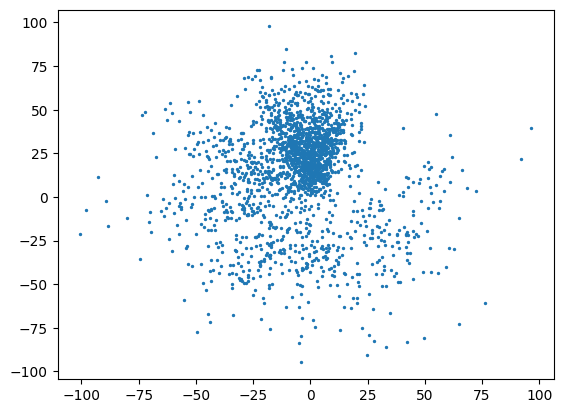

In [91]:
x_final = x_final.cpu().detach().numpy()
plt.scatter(x_final[:,0], x_final[:,1], s=2, alpha=1)#10

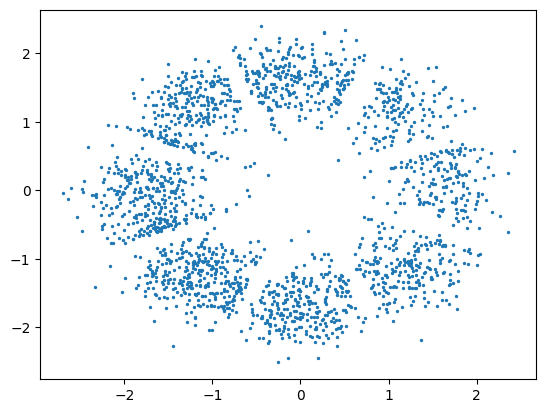

In [ ]:
#x_final = x_final.cpu().detach().numpy()
plt.scatter(x_final[:,0], x_final[:,1], s=2, alpha=1)#100

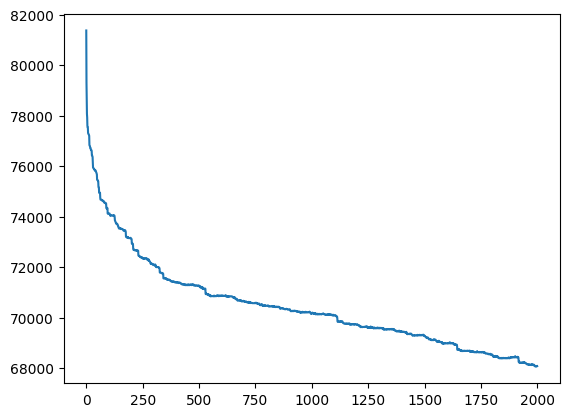

In [95]:
mcmc_loss = np.array(daps_energy.record_data['loss_lists'][2])
plt.plot(mcmc_loss)

(-5.0, 5.0)

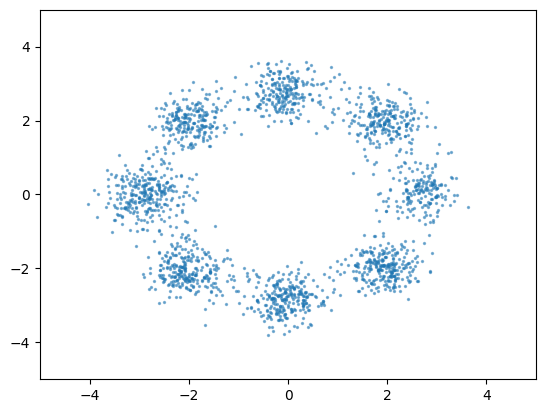

In [ ]:
xxhats = daps_energy.record_data['x0_hats']
xxhats = np.array(xxhats)
idx = 0
plt.scatter(xxhats[idx, :,0], xxhats[idx, :,1], s=2, alpha=0.5)
plt.xlim(-5, 5)
plt.ylim(-5, 5)

(-5.0, 5.0)

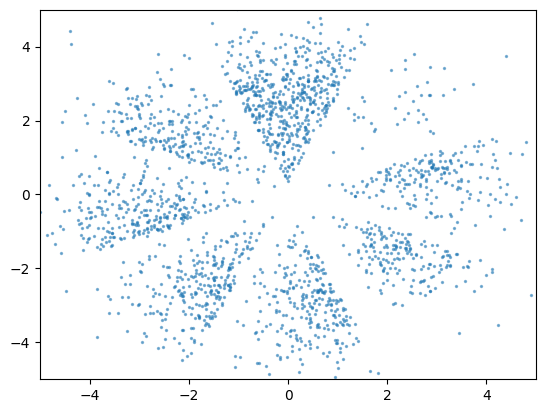

In [ ]:
xxconds = daps_energy.record_data['x0_conds']
xxconds = np.array(xxconds)
idx = 0
plt.scatter(xxconds[idx, :,0], xxconds[idx, :,1], s=2, alpha=0.5)
plt.xlim(-5, 5)
plt.ylim(-5, 5)

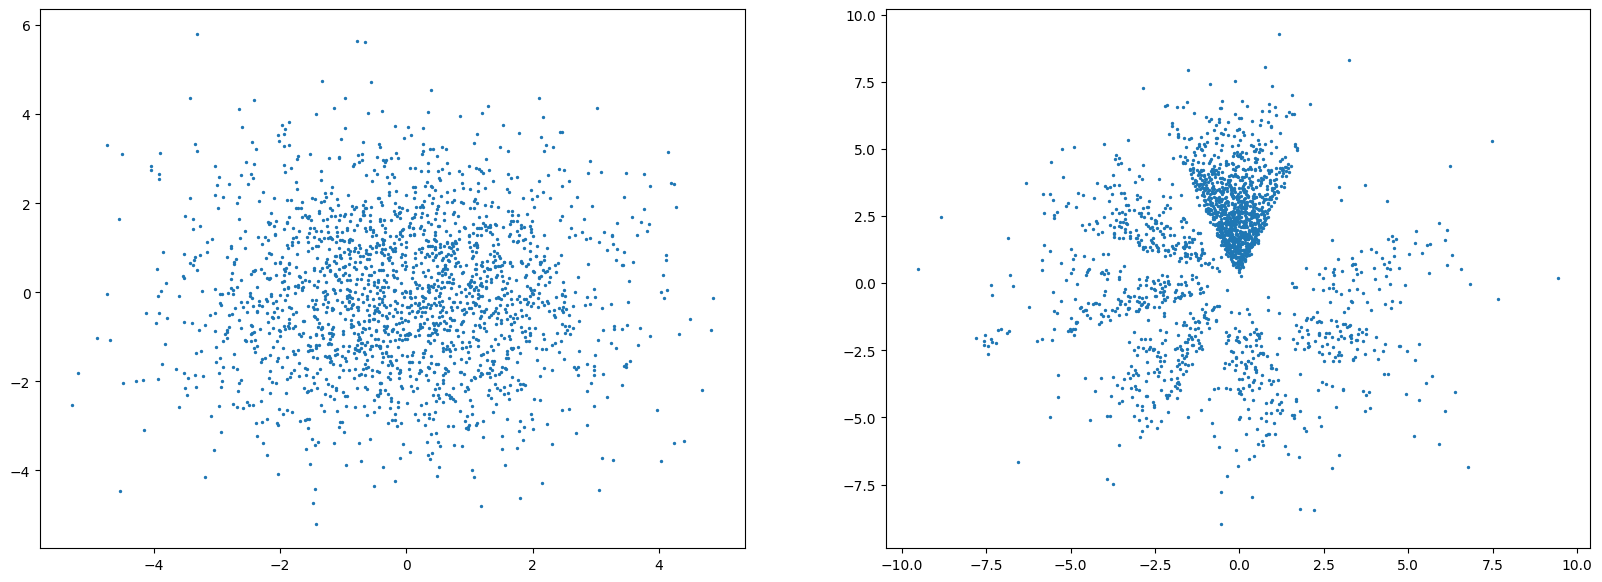

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
idn = 0
xxhats = daps_energy.record_data['x0_hats']
xxhats = np.array(xxhats)
xxconds = daps_energy.record_data['x0_conds']
xxconds = np.array(xxconds)
axes[0].scatter(xxhats[idn, :,0], xxhats[idn, :,1], s=2, alpha=1)
axes[1].scatter(xxconds[idn, :,0], xxconds[idn, :,1], s=2, alpha=1)

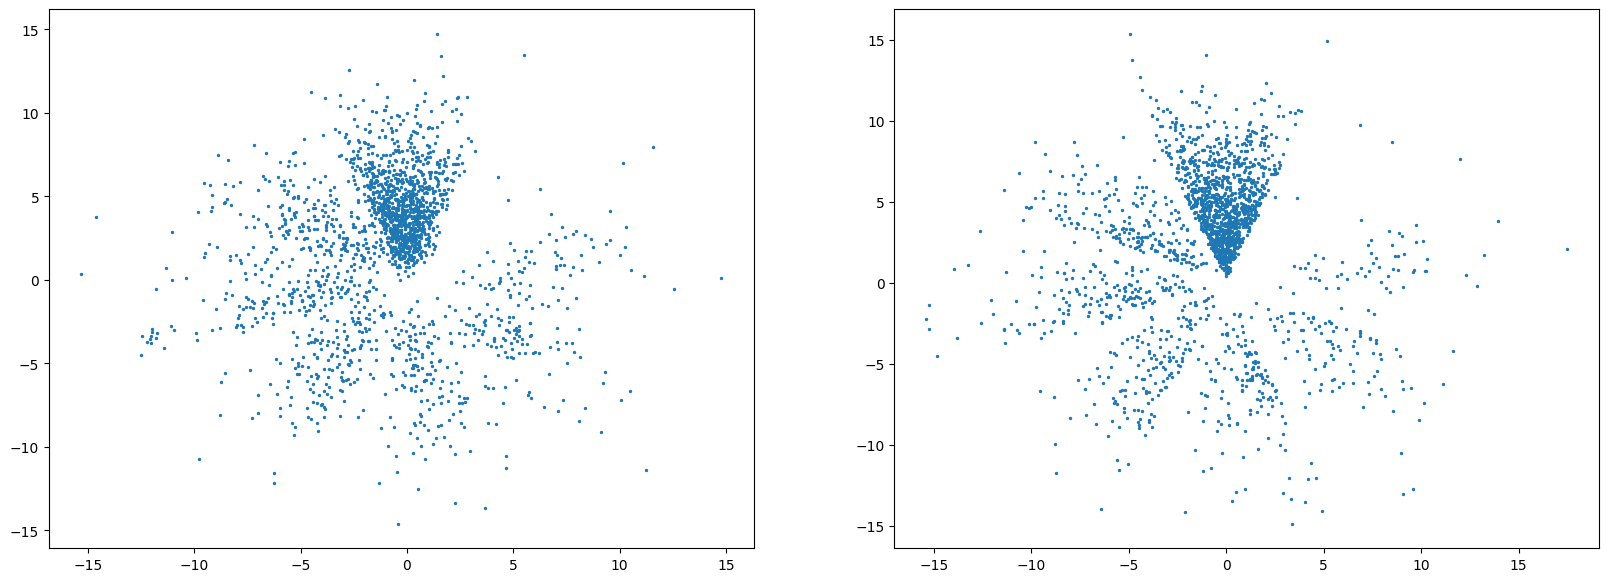

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
idn = 1
xxhats = daps_energy.record_data['x0_hats']
xxhats = np.array(xxhats)
xxconds = daps_energy.record_data['x0_conds']
xxconds = np.array(xxconds)
axes[0].scatter(xxhats[idn, :,0], xxhats[idn, :,1], s=2, alpha=1)
axes[1].scatter(xxconds[idn, :,0], xxconds[idn, :,1], s=2, alpha=1)

/tmp/ipykernel_109904/2986684473.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)


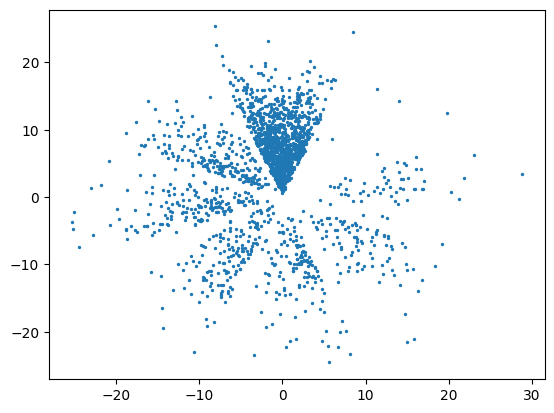

In [98]:
debug_condn = daps_energy.record_data['x0_conds'][1].to('cuda')
my_schedule = dpm_solver_pytorch.NoiseScheduleVP('linear', continuous_beta_0=0.001, continuous_beta_1=2)
test_rev_diff = RerverseDiff(my_schedule, my_score_model)
test_rev_x0 = test_rev_diff.provide_x0(debug_condn)
test_rev_x0 = test_rev_x0.cpu().numpy()
plt.scatter(test_rev_x0[:,0], test_rev_x0[:,1], s=2)